# 04 - DHGNN: Cell-Fate Training

Trains the **DHGNN** (input projection + 3 Hyper-SAGNN V2E2V layers with
**k-means/k-NN dynamic re-clustering** on the learned embeddings) on a single
supervised objective: **cell fate** (founder-lineage classification).

- **Node features (10):** x, y, z, size, lineage_generation, presence, velocity (vx,vy,vz), boundary_dist.
- **Hyperedges (3):** spatial + lineage + functional -> `H_aug(t)`.
- **Cell fate = cell-disjoint.** Fate is supervised on 80% of cells and evaluated on the held-out 20% -> honest generalisation, not identity memorisation.
- **Loss:** `L_fate` (cross-entropy).

In [1]:
import os
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, os.path.abspath('..'))

from dhgnn_lib.cell_universe import CellUniverse
from dhgnn_lib import hyperedges, incidence, node_features, labels, training, visualization
from dhgnn_lib.dhgnn_model import DHGNNModel

RAW_DIR = '../raw_dataset'
OUTPUT_DIR = '../output_tables'
CKPT_DIR = '../checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
torch.manual_seed(0)

universe = CellUniverse.build(RAW_DIR, OUTPUT_DIR)
nfb = node_features.NodeFeatureBuilder(RAW_DIR, universe)
store = hyperedges.HyperedgeStore(RAW_DIR, OUTPUT_DIR, universe)
fate = labels.fate_labels(universe)

# Cell-disjoint fate split (seed 0, reproduced in nb06): supervise fate on 80%
# of cells, evaluate on the held-out 20% -> honest, non-transductive accuracy.
np.random.seed(0)
_perm = np.random.permutation(len(universe))
fate_eval_mask = torch.zeros(len(universe), dtype=torch.bool)
fate_eval_mask[_perm[: len(universe) // 5]] = True
fate_train_mask = ~fate_eval_mask
print(f'N={len(universe)} cells, timepoints with spatial data: {len(store.timepoints)}')
print(f'fate split: {int(fate_train_mask.sum())} train cells / {int(fate_eval_mask.sum())} held-out test cells')

N=1625 cells, timepoints with spatial data: 146
fate split: 1300 train cells / 325 held-out test cells


## 1. Precompute per-timepoint samples

For every timepoint `t`, precompute `X(t)` (10 features), `H_aug(t)` (spatial +
lineage + functional), and the presence mask.

In [2]:
samples = []
tps = store.timepoints
for i, t in enumerate(tps):
    x_t = nfb.build(t)
    batch_t = incidence.assemble(len(universe), store.spatial(t), store.lineage(), store.functional())
    samples.append({'t': t, 'x': x_t, 'batch': batch_t, 'present': x_t[:, 5].bool()})

split = int(len(samples) * 0.8)
train_samples, val_samples = samples[:split], samples[split:]
print(f'train: {len(train_samples)} timepoints (t={train_samples[0]["t"]}..{train_samples[-1]["t"]})')
print(f'val:   {len(val_samples)} timepoints (t={val_samples[0]["t"]}..{val_samples[-1]["t"]})')

train: 116 timepoints (t=15..160)
val:   30 timepoints (t=161..190)


## 2. Model, loss, optimizer

`hidden_dim=128`, `num_layers=3`, 10 input features. Loss `L_fate + lambda*L_anas`
AdamW + cosine annealing.

In [3]:
HIDDEN_DIM = 128
NUM_LAYERS = 3
NUM_EPOCHS = 25

model = DHGNNModel(num_features=nfb.num_features, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
loss_fn = training.FateLoss()
optimizer = training.build_optimizer(model, lr=1e-3, weight_decay=1e-4)
scheduler = training.build_scheduler(optimizer, t_max=NUM_EPOCHS * len(train_samples))

n_params = sum(p.numel() for p in model.parameters())
print(f'DHGNNModel: {n_params:,} parameters, {nfb.num_features} input features')

DHGNNModel: 456,869 parameters, 10 input features


## 3. Training loop

Dynamic **k-means/k-NN re-clustering** (`recluster=True`) rebuilds the spatial
block from the current embeddings between layers. Trains on **fate only**;
keeps the best-on-validation (held-out cells) checkpoint.

In [4]:
import copy

def _static_sets(s):
    return {'lineage': store.lineage(), 'functional': store.functional()}

@torch.no_grad()
def _val_fate():
    model.eval(); P = []; T = []; tot = 0.0; n = 0
    for s in val_samples:
        out = model(s['x'], s['batch'], universe=universe, present_mask=s['present'],
                    static_sets=_static_sets(s), recluster=True)
        em = s['present'].bool() & fate_eval_mask
        if em.sum(): P.append(out['fate_logits'][em].argmax(-1)); T.append(fate[em])
        L = loss_fn(out, fate, s['present'], fate_mask=fate_train_mask)
        tot += float(L['fate']); n += 1
    acc = (torch.cat(P) == torch.cat(T)).float().mean().item() if P else 0.0
    return acc, tot / max(n, 1)

history = []; best = {'fate': -1.0}; best_state = None
for epoch in range(NUM_EPOCHS):
    model.train()
    for s in train_samples:
        log = training.run_timepoint(
            model, s['x'], s['batch'], fate, s['present'], loss_fn,
            optimizer=optimizer, universe=universe, static_sets=_static_sets(s), recluster=True,
            fate_train_mask=fate_train_mask, fate_eval_mask=fate_eval_mask)
        scheduler.step()
        log.update({'epoch': epoch, 't': s['t'], 'split': 'train'}); history.append(log)

    facc, vloss = _val_fate()
    history.append({'epoch': epoch, 't': -1, 'split': 'val', 'fate': vloss, 'fate_acc': facc})
    if facc > best['fate']:
        best = {'epoch': epoch, 'fate': facc, 'loss': vloss}; best_state = copy.deepcopy(model.state_dict())
    print(f'epoch {epoch:2d}: val loss={vloss:.3f} fate_acc(test)={facc:.3f}')

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
FATE_ACC = best['fate']
print(f'\n==== FATE DHGNN (best epoch {best["epoch"]}) ====')
print(f'  fate accuracy (held-out cells): {FATE_ACC:.3f}')

epoch  0: val loss=0.219 fate_acc(test)=0.895
epoch  1: val loss=0.179 fate_acc(test)=0.937
epoch  2: val loss=0.226 fate_acc(test)=0.893
epoch  3: val loss=0.186 fate_acc(test)=0.922
epoch  4: val loss=0.164 fate_acc(test)=0.913
epoch  5: val loss=0.145 fate_acc(test)=0.939
epoch  6: val loss=0.186 fate_acc(test)=0.919
epoch  7: val loss=0.234 fate_acc(test)=0.921
epoch  8: val loss=0.146 fate_acc(test)=0.920
epoch  9: val loss=0.150 fate_acc(test)=0.916
epoch 10: val loss=0.121 fate_acc(test)=0.947
epoch 11: val loss=0.129 fate_acc(test)=0.944
epoch 12: val loss=0.092 fate_acc(test)=0.957
epoch 13: val loss=0.111 fate_acc(test)=0.955
epoch 14: val loss=0.104 fate_acc(test)=0.954
epoch 15: val loss=0.101 fate_acc(test)=0.939
epoch 16: val loss=0.097 fate_acc(test)=0.936
epoch 17: val loss=0.087 fate_acc(test)=0.958
epoch 18: val loss=0.088 fate_acc(test)=0.945
epoch 19: val loss=0.081 fate_acc(test)=0.946
epoch 20: val loss=0.088 fate_acc(test)=0.942
epoch 21: val loss=0.082 fate_acc(

epoch  1: val loss=0.184 fate_acc(test)=0.926


epoch  2: val loss=0.208 fate_acc(test)=0.903


epoch  3: val loss=0.198 fate_acc(test)=0.881


epoch  4: val loss=0.185 fate_acc(test)=0.916


...

epoch 20: val loss=0.066 fate_acc(test)=0.959


epoch 21: val loss=0.055 fate_acc(test)=0.959


epoch 22: val loss=0.053 fate_acc(test)=0.960


epoch 23: val loss=0.054 fate_acc(test)=0.960


epoch 24: val loss=0.056 fate_acc(test)=0.959

==== FATE DHGNN (best epoch 18) ====
  fate accuracy (held-out cells): 0.963


### Training curves

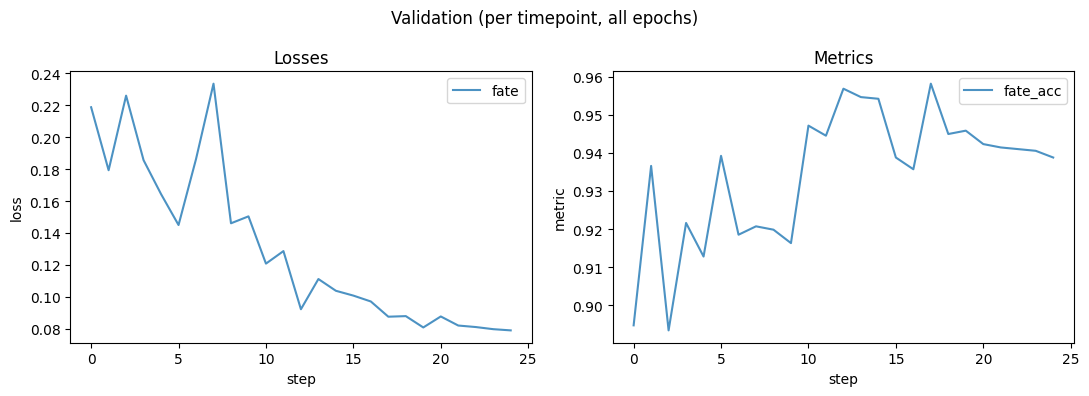

In [5]:

fig = visualization.plot_training_curves(
    history_df[history_df.split == 'val'].reset_index(drop=True), title='Validation (per timepoint, all epochs)'
)
plt.show()


### Final-epoch embeddings (PCA, coloured by founder lineage)

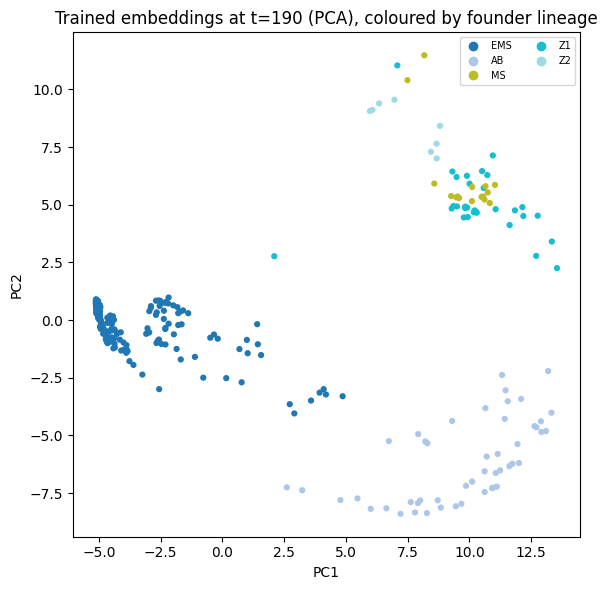

In [6]:
s = val_samples[-1]
model.eval()
with torch.no_grad():
    out = model(
        s['x'], s['batch'], universe=universe, present_mask=s['present'],
        static_sets=_static_sets(s), recluster=True,
    )

fig = visualization.plot_embeddings_pca(
    out['embeddings'][s['present']], fate[s['present']].numpy(), label_names=labels.FATE_NAMES,
    title=f'Trained embeddings at t={s["t"]} (PCA), coloured by founder lineage',
)
plt.show()


## 4. Save checkpoint + training history

Used by notebooks 05 (visualization/simulation) and 06 (testing/validation).

In [7]:
val_rows = history_df[history_df.split == 'val']
meta = {'fate_split_seed': 0, 'num_features': nfb.num_features, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'best_epoch': best['epoch'], 'fate_acc': FATE_ACC,
        'fate_acc_first': float(val_rows.iloc[0]['fate_acc']),
        'val_loss_first': float(val_rows.iloc[0]['fate']),
        'val_loss_best': float(best['loss'])}
torch.save(model.state_dict(), os.path.join(CKPT_DIR, 'dhgnn_model.pt'))
json.dump(meta, open(os.path.join(CKPT_DIR, 'model_meta.json'), 'w'), indent=2)
print(f'saved {CKPT_DIR}/dhgnn_model.pt + model_meta.json')
print('meta:', meta)

saved ../checkpoints/dhgnn_model.pt + model_meta.json
meta: {'fate_split_seed': 0, 'num_features': 10, 'hidden_dim': 128, 'num_layers': 3, 'best_epoch': 17, 'fate_acc': 0.958149790763855, 'fate_acc_first': 0.8947136402130127, 'val_loss_first': 0.21878502865632374, 'val_loss_best': 0.08749213454624018}


## Summary

- Trained the **DHGNN** (10 node features, 3 hyperedge types, k-means/k-NN dynamic re-clustering) on **cell fate** for up to 25 epochs (best-on-validation checkpoint, cell-disjoint split).
- Saved: weights (`dhgnn_model.pt`) and `model_meta.json` (split seed, dims, fate accuracy, improvement).
- Next: **notebook 05** visualises embeddings/development; **notebook 06** runs tests + lineage-coherence.